# TravelTide Mastery Project

## Kundensegmentierung und Perk-Zuweisung

### Ziel des Notebooks

In diesem Notebook werden die im Rahmen der Datenaufbereitung entwickelten
Kundenmerkmale genutzt, um Kunden mit ähnlichem Reise-, Buchungs- und
Nutzungsverhalten zu identifizieren.

Hierfür werden zunächst geeignete Merkmale für die Segmentierung ausgewählt
und vorbereitet. Anschließend werden verschiedene Verfahren zur
Kundensegmentierung untersucht:

- K-Means-Clustering
- DBSCAN
- Dimensionsreduktion mit PCA

Die Ergebnisse der Verfahren werden anhand geeigneter Kennzahlen sowie ihrer
inhaltlichen Interpretierbarkeit verglichen. Auf Grundlage der finalen
Kundensegmente werden die charakteristischen Verhaltensweisen der einzelnen
Gruppen beschrieben und verständliche Segmentbezeichnungen entwickelt.

Abschließend wird jedem Kunden ein voraussichtlich passender Benefit aus dem
geplanten TravelTide-Rewards-Programm zugeordnet:

- kostenlose Hotelmahlzeit
- kostenloses Aufgabegepäck
- keine Stornierungsgebühren
- exklusive Rabatte
- kostenlose Hotelnacht bei gemeinsamer Flug- und Hotelbuchung

Das Ergebnis ist eine finale Kundentabelle, die neben den aufbereiteten
Kundenmerkmalen auch die Segmentzugehörigkeit und den empfohlenen Benefit
enthält.

## 1. Datenimport und erste Datenprüfung

Zunächst wird die in Notebook 01 erstellte finale Kundentabelle eingelesen.
Sie enthält pro Kunde genau eine Zeile sowie die aufbereiteten demografischen,
verhaltensbezogenen und monetären Merkmale.

Vor der Segmentierung werden die Dimensionen der Tabelle, die Eindeutigkeit
der Nutzer, die Datentypen sowie die vorhandenen Spalten überprüft. Dadurch
wird sichergestellt, dass die Daten vollständig und in der erwarteten
Struktur vorliegen.

In [1]:
# Bibliotheken importieren

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

In [2]:
# Finale Kundentabelle aus der Datenaufbereitung einlesen

customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

print(f"Zeilen: {customer_features.shape[0]}")
print(f"Spalten: {customer_features.shape[1]}")

display(customer_features.head())

Zeilen: 5752
Spalten: 79


,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,customer_tenure_days,customer_tenure_months,session_count,mean_session_duration_minutes,median_session_duration_minutes,total_page_clicks,mean_page_clicks,low_click_session_rate,booking_session_count,flight_booking_session_count,hotel_booking_session_count,package_booking_session_count,cancellation_count,flight_discount_offer_count,hotel_discount_offer_count,mean_flight_discount_amount,mean_hotel_discount_amount,discounted_flight_booking_count,discounted_hotel_booking_count,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,total_flight_value_before_discount_usd,total_flight_value_after_discount_usd,total_realized_flight_spend_usd,mean_flight_booking_value_after_discount_usd,total_seats,mean_seats,total_checked_bags,mean_checked_bags,mean_fare_per_seat_after_discount_usd,return_flight_rate,cancelled_flight_count,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,total_hotel_value_before_discount_usd,mean_hotel_value_before_discount_usd,total_hotel_value_after_discount_usd,mean_hotel_value_after_discount_usd,total_realized_hotel_spend_usd,mean_completed_hotel_spend_usd,total_hotel_nights,mean_hotel_nights,total_rooms,mean_rooms,mean_hotel_price_per_room_usd,median_hotel_price_per_room_usd,unique_hotel_brands,unique_hotel_cities,extended_stay_booking_count,extended_stay_booking_share,cancelled_hotel_count,preferred_hotel_segment,preferred_hotel_city,hotel_price_tier_share_Low price,hotel_price_tier_share_Medium price,hotel_price_tier_share_High price,hotel_price_tier_share_Very high price,has_flight_booking,has_hotel_booking,has_travel_booking,checked_bags_per_seat,total_cancelled_bookings,historical_customer_value_usd
0,23557,1958-12-08,F,True,False,usa,new york,LGA,40.777,-73.872,2021-07-22,64,736,24.179,8,1.277,1.158,82,10.250,0.000,2,0,2,0,0,0,2,NaN,0.175,0,1,0.250,0.000,0.000,NaN,0.500,0.000,0.000,0.000,0.000,NaN,0.000,NaN,0.000,NaN,NaN,NaN,0.000,NaN,2.000,"3,802.000","1,901.000","3,670.500","1,835.250","3,670.500","1,835.250",20.000,10.000,3.000,1.500,177.000,177.000,2.000,2.000,1.000,0.500,0.000,Economy,Calgary,0.500,0.000,0.000,0.500,False,True,True,0.000,0.000,"3,670.500"
1,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,51,536,17.608,8,1.129,0.625,73,9.125,0.000,2,2,2,2,0,0,1,NaN,0.100,0,0,0.250,0.000,1.000,NaN,0.000,2.000,864.090,864.090,864.090,432.045,3.000,1.500,1.000,0.500,276.252,1.000,0.000,288.030,2.000,230.000,115.000,230.000,115.000,230.000,115.000,2.000,1.000,3.000,1.500,90.000,90.000,2.000,2.000,0.000,0.000,0.000,Luxury,Jacksonville,0.500,0.500,0.000,0.000,True,True,True,0.333,0.000,"1,094.090"
2,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,50,526,17.280,8,2.038,2.433,131,16.375,0.000,2,1,2,1,0,2,0,0.075,NaN,0,0,0.250,0.000,0.500,0.000,NaN,1.000,189.910,189.910,189.910,189.910,1.000,1.000,0.000,0.000,189.910,1.000,0.000,189.910,2.000,"2,199.000","1,099.500","2,199.000","1,099.500","2,199.000","1,099.500",8.000,4.000,3.000,1.500,198.500,198.500,2.000,2.000,0.000,0.000,0.000,Luxury,Edmonton,0.000,0.500,0.000,0.500,True,True,True,0.000,0.000,"2,388.910"
3,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,42,526,17.280,8,1.962,2.217,126,15.750,0.125,5,5,5,5,0,2,1,0.150,0.100,1,0,0.625,0.000,1.000,0.500,0.000,5.000,"1,242.660","1,237.693","1,237.693",247.539,5.000,1.000,2.000,0.400,247.539,1.000,0.000,247.539,5.000,"2,429.000",485.800,"2,429.000",485.800,"2,429.000",485.800,19.000,3.800,5.000,1.000,136.000,132.000,5.000,5.000,1.000,0.200,0.000,Luxury,Charlotte,0.200,0.400,0.400,0.000,True,True,True,0.400,0.000,"3,666.693"
4,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,44,519,17.050,8,12.649,2.392,240,30.000,0.000,1,1,1,1,1,1,1,NaN,NaN,0,0,0.125,0.125,1.000,0.000,0.000,1.

In [3]:
# Struktur und Datentypen prüfen

customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   user_id                                       5752 non-null   int64  
 1   birthdate                                     5752 non-null   str    
 2   gender                                        5752 non-null   str    
 3   married                                       5752 non-null   bool   
 4   has_children                                  5752 non-null   bool   
 5   home_country                                  5752 non-null   str    
 6   home_city                                     5752 non-null   str    
 7   home_airport                                  5752 non-null   str    
 8   home_airport_lat                              5752 non-null   float64
 9   home_airport_lon                              5752 non-null   float64
 10 

In [4]:
# Anzahl eindeutiger Kunden prüfen

print(
    "Eindeutige Nutzer:",
    customer_features["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    customer_features["user_id"].duplicated().sum()
)

Eindeutige Nutzer: 5752
Doppelte Nutzer: 0


In [5]:
# Alle vorhandenen Spalten (= Merkmale) übersichtlich anzeigen.

columns_overview = pd.DataFrame({
    "column": customer_features.columns,
    "dtype": customer_features.dtypes.astype(str).values,
    "missing_values": customer_features.isna().sum().values,
    "unique_values": customer_features.nunique(dropna=False).values
})

display(columns_overview)

,column,dtype,missing_values,unique_values
0,user_id,int64,0,5752
1,birthdate,str,0,4625
2,gender,str,0,3
3,married,bool,0,2
4,has_children,bool,0,2
5,home_country,str,0,2
6,home_city,str,0,105
7,home_airport,str,0,159
8,home_airport_lat,float64,0,158
9,home_airport_lon,float64,0,158


In [6]:
# Numerische und nicht numerische Spalten unterscheiden

numeric_columns = customer_features.select_dtypes(
    include="number"
).columns.tolist()

non_numeric_columns = customer_features.select_dtypes(
    exclude="number"
).columns.tolist()

print("Numerische Spalten:")
display(numeric_columns)

print("\nNicht numerische Spalten:")
display(non_numeric_columns)

Numerische Spalten:


['user_id',
 'home_airport_lat',
 'home_airport_lon',
 'age',
 'customer_tenure_days',
 'customer_tenure_months',
 'session_count',
 'mean_session_duration_minutes',
 'median_session_duration_minutes',
 'total_page_clicks',
 'mean_page_clicks',
 'low_click_session_rate',
 'booking_session_count',
 'flight_booking_session_count',
 'hotel_booking_session_count',
 'package_booking_session_count',
 'cancellation_count',
 'flight_discount_offer_count',
 'hotel_discount_offer_count',
 'mean_flight_discount_amount',
 'mean_hotel_discount_amount',
 'discounted_flight_booking_count',
 'discounted_hotel_booking_count',
 'booking_session_rate',
 'cancellation_session_rate',
 'package_booking_rate',
 'flight_discount_conversion_rate',
 'hotel_discount_conversion_rate',
 'flight_booking_count',
 'total_flight_value_before_discount_usd',
 'total_flight_value_after_discount_usd',
 'total_realized_flight_spend_usd',
 'mean_flight_booking_value_after_discount_usd',
 'total_seats',
 'mean_seats',
 'tota


Nicht numerische Spalten:


['birthdate',
 'gender',
 'married',
 'has_children',
 'home_country',
 'home_city',
 'home_airport',
 'sign_up_date',
 'preferred_hotel_segment',
 'preferred_hotel_city',
 'has_flight_booking',
 'has_hotel_booking',
 'has_travel_booking']

## 2. Merkmalsauswahl

Für die Kundensegmentierung werden Merkmale ausgewählt, die unterschiedliche
Aspekte des bisherigen Kundenverhaltens abbilden. Dazu gehören die Nutzung
der Plattform, das Buchungs- und Stornierungsverhalten, die Reaktion auf
Rabattangebote sowie das Flug- und Hotelverhalten.

Identifikationsmerkmale, demografische Angaben und geografische Koordinaten
werden nicht für die Berechnung der Cluster verwendet. Sie können später zur
inhaltlichen Beschreibung der Kundensegmente herangezogen werden.

Bei mehreren stark verwandten Merkmalen wird zunächst nur eine repräsentative
Variable ausgewählt. Dadurch soll verhindert werden, dass einzelne
Verhaltensaspekte im Clustering mehrfach gewichtet werden.

In [7]:
# Merkmale nach Funktion einteilen.

identifier_columns = [
    "user_id"
]

descriptive_candidates = [
    "age",
    "gender",
    "married",
    "has_children",
    "home_country",
    "customer_tenure_days",
    "customer_tenure_months"
]

descriptive_columns = [
    column
    for column in descriptive_candidates
    if column in customer_features.columns
]

behavior_columns = [
    column
    for column in numeric_columns
    if column not in identifier_columns + descriptive_columns
]

print("Identifikationsmerkmale:")
print(identifier_columns)

print("\nBeschreibende Merkmale:")
print(descriptive_columns)

print("\nMögliche Verhaltensmerkmale:")
display(behavior_columns)

Identifikationsmerkmale:
['user_id']

Beschreibende Merkmale:
['age', 'gender', 'married', 'has_children', 'home_country', 'customer_tenure_days', 'customer_tenure_months']

Mögliche Verhaltensmerkmale:


['home_airport_lat',
 'home_airport_lon',
 'session_count',
 'mean_session_duration_minutes',
 'median_session_duration_minutes',
 'total_page_clicks',
 'mean_page_clicks',
 'low_click_session_rate',
 'booking_session_count',
 'flight_booking_session_count',
 'hotel_booking_session_count',
 'package_booking_session_count',
 'cancellation_count',
 'flight_discount_offer_count',
 'hotel_discount_offer_count',
 'mean_flight_discount_amount',
 'mean_hotel_discount_amount',
 'discounted_flight_booking_count',
 'discounted_hotel_booking_count',
 'booking_session_rate',
 'cancellation_session_rate',
 'package_booking_rate',
 'flight_discount_conversion_rate',
 'hotel_discount_conversion_rate',
 'flight_booking_count',
 'total_flight_value_before_discount_usd',
 'total_flight_value_after_discount_usd',
 'total_realized_flight_spend_usd',
 'mean_flight_booking_value_after_discount_usd',
 'total_seats',
 'mean_seats',
 'total_checked_bags',
 'mean_checked_bags',
 'mean_fare_per_seat_after_discou

In [8]:
# Vorauswahl potenzieller Clustering-Merkmale

clustering_feature_candidates = [
    # Nutzung der Plattform
    "mean_session_duration_minutes",
    "mean_page_clicks",
    "low_click_session_rate",

    # Allgemeines Buchungs- und Stornierungsverhalten
    "booking_session_rate",
    "cancellation_session_rate",
    "package_booking_rate",

    # Reaktion auf Rabattangebote
    "flight_discount_conversion_rate",
    "hotel_discount_conversion_rate",

    # Flugverhalten
    "flight_booking_count",
    "mean_seats",
    "checked_bags_per_seat",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",

    # Hotelverhalten
    "hotel_booking_count",
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "extended_stay_booking_share",

    # Bisheriger monetärer Kundenwert
    "historical_customer_value_usd"
]

# Prüfen, ob alle ausgewählten Spalten vorhanden sind

missing_candidate_columns = [
    column
    for column in clustering_feature_candidates
    if column not in customer_features.columns
]

print("Anzahl vorausgewählter Merkmale:",
      len(clustering_feature_candidates))

print("Nicht gefundene Merkmale:",
      missing_candidate_columns)

Anzahl vorausgewählter Merkmale: 18
Nicht gefundene Merkmale: []


In [9]:
# Arbeitstabelle für die weitere Merkmalsprüfung erstellen

clustering_candidates = (
    customer_features[
        ["user_id"] + clustering_feature_candidates
    ]
    .copy()
)

display(clustering_candidates.head())

,user_id,mean_session_duration_minutes,mean_page_clicks,low_click_session_rate,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share,historical_customer_value_usd
0,23557,1.277,10.250,0.000,0.250,0.000,0.000,NaN,0.500,0.000,NaN,0.000,NaN,NaN,2.000,10.000,177.000,0.500,"3,670.500"
1,94883,1.129,9.125,0.000,0.250,0.000,1.000,NaN,0.000,2.000,1.500,0.333,1.000,288.030,2.000,1.000,90.000,0.000,"1,094.090"
2,101486,2.038,16.375,0.000,0.250,0.000,0.500,0.000,NaN,1.000,1.000,0.000,1.000,189.910,2.000,4.000,198.500,0.000,"2,388.910"
3,101961,1.962,15.750,0.125,0.625,0.000,1.000,0.500,0.000,5.000,1.000,0.400,1.000,247.539,5.000,3.800,132.000,0.200,"3,666.693"
4,106907,12.649,30.000,0.000,0.125,0.125,1.000,0.000,0.000,1.000,6.000,0.833,1.000,"2,317.010",1.000,11.000,129.000,0.000,0.000


In [10]:
# Statistische Übersicht der vorausgewählten Merkmale

candidate_overview = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .describe()
    .T
)

candidate_overview["missing_values"] = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .isna()
    .sum()
)

candidate_overview["missing_share"] = (
    candidate_overview["missing_values"]
    / len(clustering_candidates)
)

candidate_overview["unique_values"] = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .nunique()
)

display(candidate_overview)

,count,mean,std,min,25%,50%,75%,max,missing_values,missing_share,unique_values
mean_session_duration_minutes,"5,752.000",3.116,4.002,0.525,1.567,1.948,2.465,35.627,0,0.000,2514
mean_page_clicks,"5,752.000",17.685,8.733,4.125,12.625,15.625,19.688,109.125,0,0.000,681
low_click_session_rate,"5,752.000",0.009,0.032,0.000,0.000,0.000,0.000,0.250,0,0.000,6
booking_session_rate,"5,752.000",0.336,0.184,0.000,0.222,0.375,0.500,1.000,0,0.000,28
cancellation_session_rate,"5,752.000",0.012,0.038,0.000,0.000,0.000,0.000,0.250,0,0.000,8
package_booking_rate,"5,360.000",0.722,0.319,0.000,0.500,0.750,1.000,1.000,392,0.068,17
flight_discount_conversion_rate,"4,617.000",0.231,0.348,0.000,0.000,0.000,0.500,1.000,1135,0.197,10
hotel_discount_conversion_rate,"4,032.000",0.286,0.388,0.000,0.000,0.000,0.500,1.000,1720,0.299,11
flight_booking_count,"5,752.000",2.357,1.497,0.000,1.000,2.000,3.000,8.000,0,0.000,9
mean_seats,"5,057.000",1.212,0.434,1.000,1.000,1.000,1.333,6.000,695,0.121,31


In [11]:
# Fehlende Werte der Kandidaten übersichtlich darstellen

missing_overview = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={
        "sum": "missing_values",
        "mean": "missing_share"
    })
    .sort_values(
        "missing_values",
        ascending=False
    )
)

display(missing_overview)

,missing_values,missing_share
hotel_discount_conversion_rate,"1,720.000",0.299
flight_discount_conversion_rate,"1,135.000",0.197
weighted_fare_per_seat_after_discount_usd,695.000,0.121
return_flight_rate,695.000,0.121
mean_seats,695.000,0.121
median_hotel_price_per_room_usd,512.000,0.089
mean_hotel_nights,512.000,0.089
package_booking_rate,392.000,0.068
mean_page_clicks,0.000,0.000
mean_session_duration_minutes,0.000,0.000


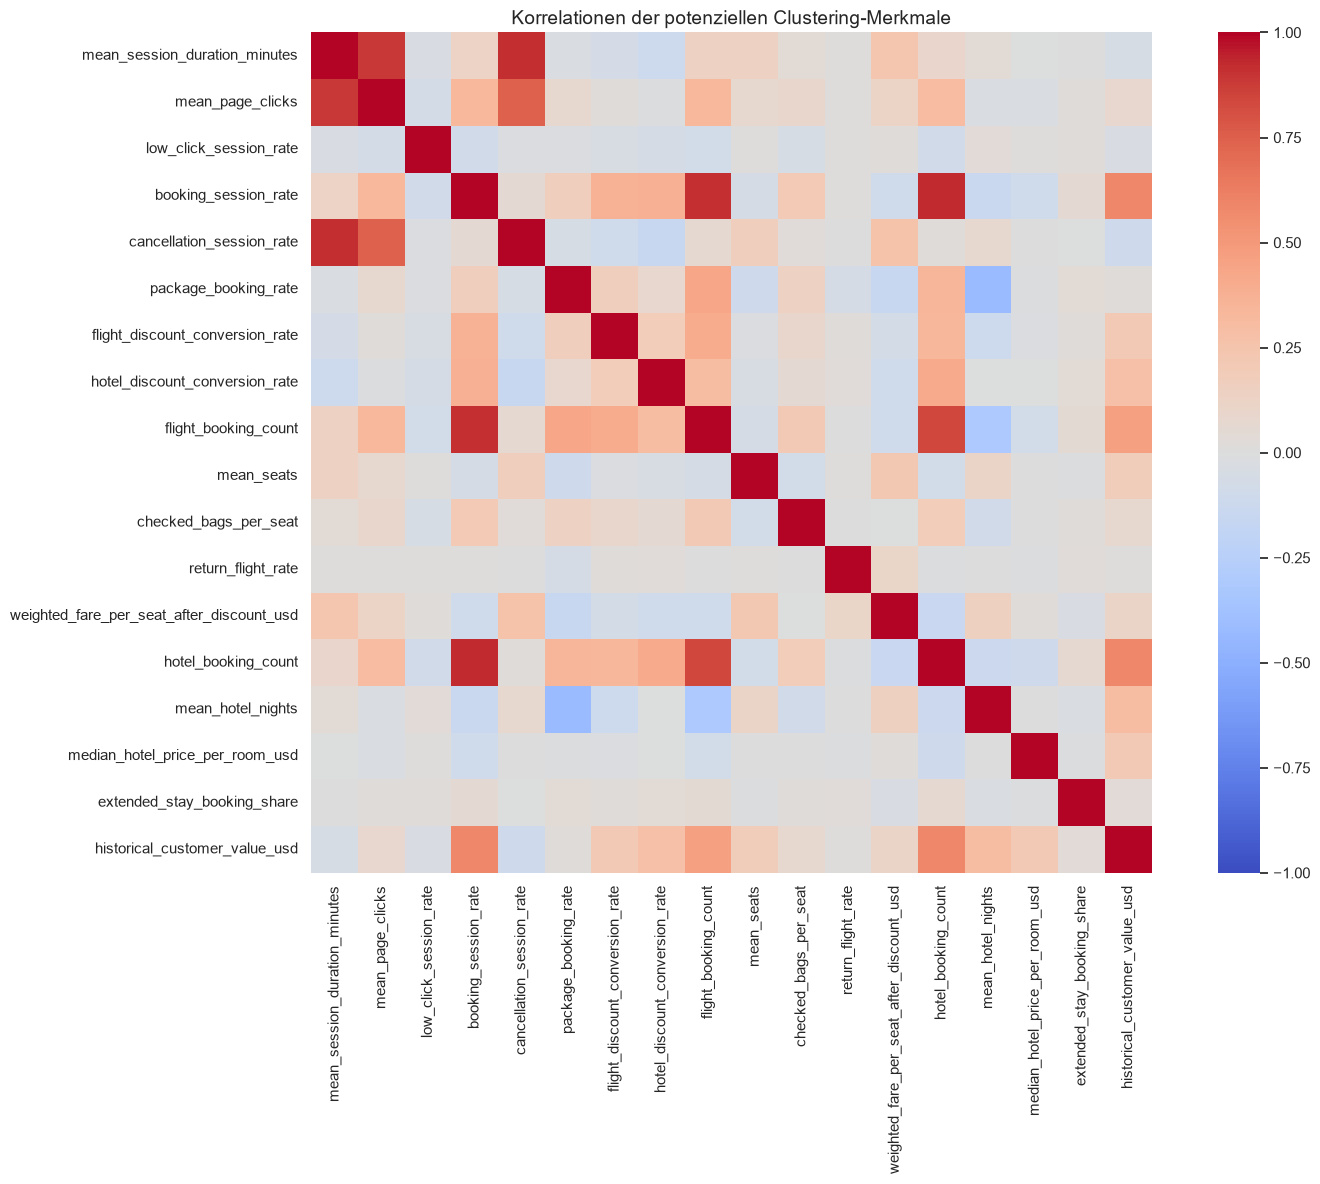

In [12]:
# Korrelationsmatrix der vorausgewählten Merkmale

correlation_matrix = (
    clustering_candidates[
        clustering_feature_candidates
    ]
    .corr()
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Korrelationen der potenziellen Clustering-Merkmale",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [13]:
# Stark korrelierte Merkmalspaare identifizieren

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

strong_correlations = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_correlations.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

strong_correlations["absolute_correlation"] = (
    strong_correlations["correlation"].abs()
)

strong_correlations = (
    strong_correlations[
        strong_correlations["absolute_correlation"] >= 0.70
    ]
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)

display(strong_correlations)

,feature_1,feature_2,correlation,absolute_correlation
67,booking_session_rate,hotel_booking_count,0.927,0.927
4,mean_session_duration_minutes,cancellation_session_rate,0.915,0.915
62,booking_session_rate,flight_booking_count,0.909,0.909
1,mean_session_duration_minutes,mean_page_clicks,0.885,0.885
157,flight_booking_count,hotel_booking_count,0.836,0.836
22,mean_page_clicks,cancellation_session_rate,0.746,0.746


count   5,752.000
mean       -0.043
std         0.314
min        -1.000
25%        -0.111
50%         0.000
75%         0.000
max         1.000
Name: travel_product_balance, dtype: float64

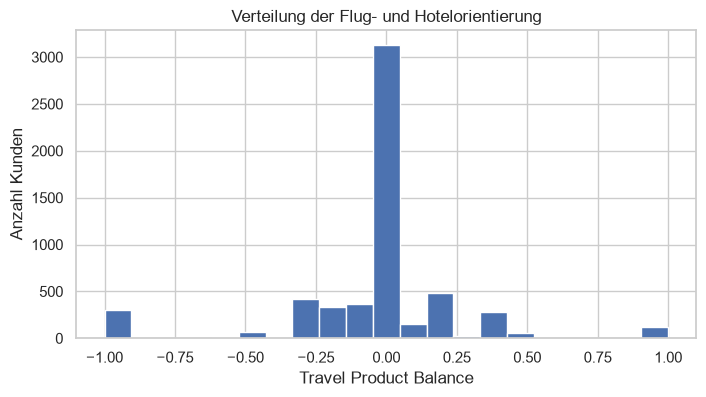

In [14]:
# Verhältnis zwischen Flug- und Hotelbuchungen abbilden

total_travel_bookings = (
    customer_features["flight_booking_count"]
    + customer_features["hotel_booking_count"]
)

customer_features["travel_product_balance"] = np.where(
    total_travel_bookings > 0,
    (
        customer_features["flight_booking_count"]
        - customer_features["hotel_booking_count"]
    )
    / total_travel_bookings,
    0
)

display(
    customer_features["travel_product_balance"]
    .describe()
)

customer_features["travel_product_balance"].hist(
    bins=21,
    figsize=(8, 4)
)

plt.title("Verteilung der Flug- und Hotelorientierung")
plt.xlabel("Travel Product Balance")
plt.ylabel("Anzahl Kunden")
plt.show()

### Ergebnis der Merkmalsauswahl

Die Prüfung der potenziellen Clustering-Merkmale zeigte mehrere starke
inhaltliche Überschneidungen. Die durchschnittliche Sitzungsdauer und die
durchschnittliche Zahl der Seitenklicks korrelieren stark miteinander und
mit der Stornierungsrate. Da die Stornierungsrate für die Beschreibung des
Reiseverhaltens unmittelbar relevant ist, wird sie beibehalten, während die
beiden allgemeinen Nutzungsmerkmale aus der weiteren Segmentierung
ausgeschlossen werden.

Auch die Buchungsrate sowie die Anzahl der Flug- und Hotelbuchungen weisen
starke Zusammenhänge auf. Um eine Mehrfachgewichtung der allgemeinen
Buchungsaktivität zu vermeiden, wird die Buchungsrate beibehalten. Ergänzend
wird mit `travel_product_balance` ein Merkmal entwickelt, das zwischen einer
eher flugorientierten und einer eher hotelorientierten Nutzung unterscheidet.

Die verbleibenden Merkmale bilden das Buchungs- und Stornierungsverhalten,
die Reaktion auf Rabattangebote, die Flug- und Hotelpräferenzen sowie den
historischen Kundenwert ab. Demografische und geografische Merkmale werden
nicht zur Berechnung der Cluster verwendet, sondern später zur Beschreibung
und Interpretation der entstandenen Kundensegmente herangezogen.

## 3. Datenvorbereitung für das Clustering

Distanzbasierte Clustering-Verfahren wie K-Means und DBSCAN reagieren
empfindlich auf fehlende Werte, stark schiefe Verteilungen und
unterschiedliche Größenordnungen der Merkmale.

Die ausgewählten Variablen werden daher vor dem Clustering systematisch
vorbereitet. Zunächst werden strukturell fehlende Werte behandelt.
Anschließend werden stark rechtsschiefe monetäre und mengenbezogene Merkmale
transformiert. Abschließend werden alle Clustering-Merkmale standardisiert,
damit sie unabhängig von ihrer ursprünglichen Einheit vergleichbar in die
Distanzberechnung einfließen.

In [15]:
# Finale Merkmale für die weitere Datenvorbereitung

final_clustering_features = [
    # Allgemeines Buchungsverhalten
    "booking_session_rate",
    "cancellation_session_rate",
    "package_booking_rate",

    # Reaktion auf Rabattangebote
    "flight_discount_conversion_rate",
    "hotel_discount_conversion_rate",

    # Verhältnis zwischen Flug- und Hotelnutzung
    "travel_product_balance",

    # Flugverhalten
    "mean_seats",
    "checked_bags_per_seat",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",

    # Hotelverhalten
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "extended_stay_booking_share",

    # Historischer Kundenwert
    "historical_customer_value_usd"
]

In [16]:
# Nutzer-IDs separat sichern

cluster_user_ids = customer_features["user_id"].copy()


# Arbeitstabelle mit den finalen Clustering-Merkmalen erstellen

X_cluster = (
    customer_features[
        final_clustering_features
    ]
    .copy()
)

print("Dimensionen der Merkmalstabelle:")
print(X_cluster.shape)

display(X_cluster.head())

Dimensionen der Merkmalstabelle:
(5752, 14)


,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,travel_product_balance,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share,historical_customer_value_usd
0,0.250,0.000,0.000,NaN,0.500,-1.000,NaN,0.000,NaN,NaN,10.000,177.000,0.500,"3,670.500"
1,0.250,0.000,1.000,NaN,0.000,0.000,1.500,0.333,1.000,288.030,1.000,90.000,0.000,"1,094.090"
2,0.250,0.000,0.500,0.000,NaN,-0.333,1.000,0.000,1.000,189.910,4.000,198.500,0.000,"2,388.910"
3,0.625,0.000,1.000,0.500,0.000,0.000,1.000,0.400,1.000,247.539,3.800,132.000,0.200,"3,666.693"
4,0.125,0.125,1.000,0.000,0.000,0.000,6.000,0.833,1.000,"2,317.010",11.000,129.000,0.000,0.000


In [17]:
# Fehlende Werte vor der Behandlung

missing_before = (
    X_cluster
    .isna()
    .sum()
    .to_frame("missing_before")
)

missing_before["missing_share"] = (
    missing_before["missing_before"]
    / len(X_cluster)
)

display(
    missing_before[
        missing_before["missing_before"] > 0
    ]
    .sort_values(
        "missing_before",
        ascending=False
    )
)

,missing_before,missing_share
hotel_discount_conversion_rate,1720,0.299
flight_discount_conversion_rate,1135,0.197
mean_seats,695,0.121
return_flight_rate,695,0.121
weighted_fare_per_seat_after_discount_usd,695,0.121
mean_hotel_nights,512,0.089
median_hotel_price_per_room_usd,512,0.089
package_booking_rate,392,0.068


In [18]:
# Fehlender Werte mit 0 ersetzen (Null bedeutet kein beobachtetes entsprechendes Verhalten).

zero_imputation_columns = [
    "package_booking_rate",
    "flight_discount_conversion_rate",
    "hotel_discount_conversion_rate"
]

X_cluster[zero_imputation_columns] = (
    X_cluster[zero_imputation_columns]
    .fillna(0)
)

In [19]:
# Fehlende Flug- und Hotelmerkmale mit dem Median der jeweils vorhandenen Werte ersetzen.

median_imputation_columns = [
    "mean_seats",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd"
]

imputation_values = {}

for column in median_imputation_columns:
    column_median = customer_features[column].median()

    imputation_values[column] = column_median

    X_cluster[column] = (
        X_cluster[column]
        .fillna(column_median)
    )

display(
    pd.Series(
        imputation_values,
        name="imputation_value"
    )
)

mean_seats                                    1.000
return_flight_rate                            1.000
weighted_fare_per_seat_after_discount_usd   345.028
mean_hotel_nights                             3.000
median_hotel_price_per_room_usd             152.500
Name: imputation_value, dtype: float64

In [20]:
# Prüfen, ob noch fehlende Werte vorhanden sind

remaining_missing_values = (
    X_cluster
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(remaining_missing_values)

print(
    "Fehlende Werte insgesamt:",
    X_cluster.isna().sum().sum()
)

booking_session_rate                         0
cancellation_session_rate                    0
package_booking_rate                         0
flight_discount_conversion_rate              0
hotel_discount_conversion_rate               0
travel_product_balance                       0
mean_seats                                   0
checked_bags_per_seat                        0
return_flight_rate                           0
weighted_fare_per_seat_after_discount_usd    0
mean_hotel_nights                            0
median_hotel_price_per_room_usd              0
extended_stay_booking_share                  0
historical_customer_value_usd                0
dtype: int64

Fehlende Werte insgesamt: 0


### Behandlung fehlender Werte

Die fehlenden Werte der ausgewählten Merkmale sind strukturell bedingt.
Fehlende Buchungs- und Rabattquoten werden mit 0 ersetzt, wenn kein
entsprechendes Verhalten beobachtet wurde.

Bei Kunden ohne Flug- oder Hotelbuchung sind typische Werte wie der
Flugpreis, die Sitzplatzanzahl, die Aufenthaltsdauer oder der Hotelpreis
hingegen nicht definiert. Diese Merkmale werden mit dem Median der
vorhandenen Beobachtungen imputiert. Dadurch werden Kunden ohne das
jeweilige Reiseprodukt nicht allein aufgrund künstlicher Nullwerte zu
extremen Beobachtungen. Die grundsätzliche Flug- beziehungsweise
Hotelorientierung wird separat durch `travel_product_balance` und die
Buchungsrate abgebildet.

In [21]:
# Auf unendliche Werte prüfen

infinite_values = np.isinf(
    X_cluster.select_dtypes(include="number")
).sum()

display(
    infinite_values[
        infinite_values > 0
    ]
)

print(
    "Unendliche Werte insgesamt:",
    infinite_values.sum()
)

Series([], dtype: int64)

Unendliche Werte insgesamt: 0


In [22]:
# Statistische Übersicht nach der Imputation

display(
    X_cluster
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
booking_session_rate,"5,752.000",0.336,0.184,0.000,0.222,0.375,0.500,1.000
cancellation_session_rate,"5,752.000",0.012,0.038,0.000,0.000,0.000,0.000,0.250
package_booking_rate,"5,752.000",0.673,0.358,0.000,0.500,0.750,1.000,1.000
flight_discount_conversion_rate,"5,752.000",0.186,0.325,0.000,0.000,0.000,0.333,1.000
hotel_discount_conversion_rate,"5,752.000",0.200,0.350,0.000,0.000,0.000,0.333,1.000
travel_product_balance,"5,752.000",-0.043,0.314,-1.000,-0.111,0.000,0.000,1.000
mean_seats,"5,752.000",1.187,0.412,1.000,1.000,1.000,1.250,6.000
checked_bags_per_seat,"5,752.000",0.443,0.402,0.000,0.000,0.429,0.667,3.000
return_flight_rate,"5,752.000",0.962,0.136,0.000,1.000,1.000,1.000,1.000
weighted_fare_per_seat_after_discount_usd,"5,752.000",391.570,270.515,5.350,259.783,345.028,444.774,"2,656.360"


In [23]:
# Schiefe aller Clustering-Merkmale berechnen

skewness_before = (
    X_cluster
    .skew()
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame("skewness_before")
)

display(skewness_before)

,skewness_before
return_flight_rate,-4.531
mean_seats,4.467
extended_stay_booking_share,4.081
weighted_fare_per_seat_after_discount_usd,3.732
cancellation_session_rate,2.927
mean_hotel_nights,2.603
median_hotel_price_per_room_usd,2.345
historical_customer_value_usd,2.253
flight_discount_conversion_rate,1.589
hotel_discount_conversion_rate,1.469


In [24]:
# Neue vorbereitete Merkmalstabelle erstellen

X_prepared = X_cluster.copy()


# Produktbezogene Merkmale logarithmisch transformieren

log_transformations = {
    "weighted_fare_per_seat_after_discount_usd":
        "log_weighted_fare_per_seat",

    "median_hotel_price_per_room_usd":
        "log_median_hotel_price_per_room",

    "mean_hotel_nights":
        "log_mean_hotel_nights"
}

for original_column, transformed_column in log_transformations.items():
    X_prepared[transformed_column] = np.log1p(
        X_prepared[original_column]
    )


# Historischen Kundenwert weniger stark transformieren

X_prepared["sqrt_historical_customer_value"] = np.sqrt(
    X_prepared["historical_customer_value_usd"]
)


# Ursprüngliche Varianten entfernen

columns_to_remove = (
    list(log_transformations.keys())
    + ["historical_customer_value_usd"]
)

X_prepared = X_prepared.drop(
    columns=columns_to_remove
)

In [25]:
# Schiefe nach der Transformation prüfen

skewness_after = (
    X_prepared
    .skew()
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame("skewness_after")
)

display(skewness_after)

,skewness_after
return_flight_rate,-4.531
mean_seats,4.467
extended_stay_booking_share,4.081
cancellation_session_rate,2.927
flight_discount_conversion_rate,1.589
hotel_discount_conversion_rate,1.469
checked_bags_per_seat,0.968
package_booking_rate,-0.793
travel_product_balance,-0.663
log_mean_hotel_nights,0.582


In [26]:
# Schiefe vor und nach der Transformation vergleichen

transformation_check = pd.DataFrame({
    "feature": [
        "historical_customer_value_usd",
        "weighted_fare_per_seat_after_discount_usd",
        "median_hotel_price_per_room_usd",
        "mean_hotel_nights"
    ],
    "skewness_before": [
        X_cluster["historical_customer_value_usd"].skew(),
        X_cluster["weighted_fare_per_seat_after_discount_usd"].skew(),
        X_cluster["median_hotel_price_per_room_usd"].skew(),
        X_cluster["mean_hotel_nights"].skew()
    ],
    "transformed_feature": [
        "sqrt_historical_customer_value",
        "log_weighted_fare_per_seat",
        "log_median_hotel_price_per_room",
        "log_mean_hotel_nights"
    ],
    "skewness_after": [
        X_prepared["sqrt_historical_customer_value"].skew(),
        X_prepared["log_weighted_fare_per_seat"].skew(),
        X_prepared["log_median_hotel_price_per_room"].skew(),
        X_prepared["log_mean_hotel_nights"].skew()
    ]
})

display(transformation_check)

,feature,skewness_before,transformed_feature,skewness_after
0,historical_customer_value_usd,2.253,sqrt_historical_customer_value,0.104
1,weighted_fare_per_seat_after_discount_usd,3.732,log_weighted_fare_per_seat,-0.555
2,median_hotel_price_per_room_usd,2.345,log_median_hotel_price_per_room,0.022
3,mean_hotel_nights,2.603,log_mean_hotel_nights,0.582


### Transformation stark schiefer Merkmale

Monetäre Merkmale und Aufenthaltsdauern weisen teilweise stark
rechtsschiefe Verteilungen auf. Wenige besonders hohe Werte könnten die
Distanzberechnung und damit insbesondere das K-Means-Ergebnis übermäßig
beeinflussen.

Der historische Kundenwert, der gewichtete Flugpreis pro Sitzplatz, der
mediane Hotelpreis pro Zimmer und die durchschnittliche Aufenthaltsdauer
werden deshalb mit `log1p` transformiert. Die Transformation reduziert den
Einfluss extremer Werte, erhält aber die Reihenfolge der Kunden innerhalb
des jeweiligen Merkmals.

In [27]:
# StandardScaler importieren

from sklearn.preprocessing import StandardScaler

In [28]:
# Merkmale standardisieren

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_prepared),
    columns=X_prepared.columns,
    index=X_prepared.index
)

In [29]:
# Mittelwerte und Standardabweichungen prüfen

scaling_check = pd.DataFrame({
    "mean": X_scaled.mean(),
    "std": X_scaled.std(ddof=0),
    "minimum": X_scaled.min(),
    "maximum": X_scaled.max()
})

display(scaling_check)

,mean,std,minimum,maximum
booking_session_rate,0.000,1.000,-1.825,3.613
cancellation_session_rate,-0.000,1.000,-0.324,6.335
package_booking_rate,0.000,1.000,-1.880,0.915
flight_discount_conversion_rate,0.000,1.000,-0.571,2.508
hotel_discount_conversion_rate,0.000,1.000,-0.572,2.282
travel_product_balance,0.000,1.000,-3.050,3.322
mean_seats,0.000,1.000,-0.453,11.674
checked_bags_per_seat,-0.000,1.000,-1.101,6.354
return_flight_rate,0.000,1.000,-7.091,0.280
extended_stay_booking_share,0.000,1.000,-0.313,6.630


In [30]:
# Finale technische Prüfung

print("Fehlende Werte:", X_scaled.isna().sum().sum())
print("Unendliche Werte:", np.isinf(X_scaled).sum().sum())
print("Dimensionen:", X_scaled.shape)

Fehlende Werte: 0
Unendliche Werte: 0
Dimensionen: (5752, 14)


### Ergebnis der Datenvorbereitung

Die ausgewählten Merkmale wurden vollständig für die distanzbasierten
Clustering-Verfahren vorbereitet. Strukturell fehlende Buchungs- und
Rabattquoten wurden mit 0 ersetzt. Nicht definierbare typische Flug- und
Hotelwerte wurden dagegen mit dem Median der vorhandenen Beobachtungen
imputiert, damit Kunden ohne das jeweilige Reiseprodukt nicht durch
künstliche Nullwerte zu extremen Beobachtungen werden.

Der historische Kundenwert wurde mit einer Quadratwurzeltransformation
aufbereitet. Der Flugpreis pro Sitzplatz, der Hotelpreis pro Zimmer und die
durchschnittliche Zahl der Hotelnächte wurden logarithmisch transformiert.
Dadurch konnte die Schiefe dieser kontinuierlichen Merkmale deutlich
reduziert werden.

Anschließend wurden sämtliche Merkmale mit dem StandardScaler auf einen
Mittelwert von 0 und eine Standardabweichung von 1 standardisiert. Die
fertige Merkmalstabelle enthält 5.752 Kunden und 14 Clustering-Merkmale
sowie keine fehlenden oder unendlichen Werte.

Einzelne seltene Verhaltensweisen wie Stornierungen, Extended Stays,
größere Sitzplatzbuchungen oder Flüge ohne Rückflug bleiben naturgemäß
schief verteilt. Bei der Bewertung der Cluster wird deshalb zusätzlich
geprüft, ob sehr kleine Gruppen allein durch solche seltenen Ausprägungen
entstehen oder ob sie fachlich sinnvolle Kundensegmente darstellen.

## 4. K-Means-Clustering

K-Means teilt die Kunden in eine vorgegebene Anzahl von Clustern ein.
Dabei werden Kunden so zugeordnet, dass die Beobachtungen innerhalb eines
Clusters möglichst ähnlich und die verschiedenen Cluster möglichst
unterschiedlich sind.

Da die geeignete Anzahl der Cluster nicht im Voraus bekannt ist, werden
mehrere Lösungen mit unterschiedlichen Werten für \(k\) untersucht. Zur
Bewertung werden die Elbow-Methode, der Silhouette Score und die Verteilung
der Kunden auf die Cluster herangezogen.

Die statistischen Kennzahlen werden nicht isoliert betrachtet. Die finale
Clusterzahl soll zusätzlich ausreichend große, stabile und fachlich
interpretierbare Kundensegmente ergeben.

In [31]:
# Benötigte Bibliotheken importieren

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [32]:
# Zu untersuchende Clusterzahlen

k_values = range(2, 11)


# Ergebnisse sammeln

kmeans_results = []
kmeans_models = {}


for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans.fit_predict(
        X_scaled
    )

    # Modell speichern
    kmeans_models[k] = kmeans

    # Clustergrößen berechnen
    cluster_sizes = pd.Series(
        cluster_labels
    ).value_counts()

    smallest_cluster_size = cluster_sizes.min()
    largest_cluster_size = cluster_sizes.max()

    # Bewertungskennzahlen speichern
    kmeans_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(
            X_scaled,
            cluster_labels
        ),
        "smallest_cluster_size": smallest_cluster_size,
        "smallest_cluster_share": (
            smallest_cluster_size
            / len(X_scaled)
        ),
        "largest_cluster_size": largest_cluster_size,
        "largest_cluster_share": (
            largest_cluster_size
            / len(X_scaled)
        )
    })


# Ergebnistabelle erstellen

kmeans_evaluation = pd.DataFrame(
    kmeans_results
)

display(kmeans_evaluation)

,k,inertia,silhouette_score,smallest_cluster_size,smallest_cluster_share,largest_cluster_size,largest_cluster_share
0,2,"71,319.260",0.175,974,0.169,4778,0.831
1,3,"65,328.869",0.195,553,0.096,4289,0.746
2,4,"60,114.489",0.142,554,0.096,2338,0.406
3,5,"56,401.164",0.150,386,0.067,2175,0.378
4,6,"53,031.679",0.157,356,0.062,2013,0.350
5,7,"50,022.066",0.171,320,0.056,1842,0.320
6,8,"46,874.973",0.189,272,0.047,2148,0.373
7,9,"44,502.713",0.182,261,0.045,1429,0.248
8,10,"42,665.705",0.182,201,0.035,1345,0.234


### Elbow-Methode

Die Elbow-Methode untersucht, wie stark sich die Streuung innerhalb der
Cluster durch zusätzliche Cluster reduziert. Ein geeigneter Wert für \(k\)
liegt häufig an dem Punkt, an dem die Inertia nicht mehr stark, sondern nur
noch schrittweise sinkt.

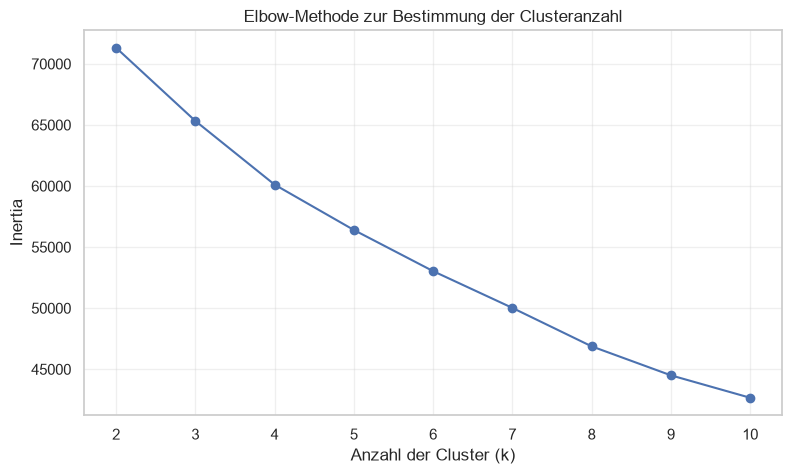

In [33]:
# Elbow-Diagramm

plt.figure(figsize=(9, 5))

plt.plot(
    kmeans_evaluation["k"],
    kmeans_evaluation["inertia"],
    marker="o"
)

plt.title(
    "Elbow-Methode zur Bestimmung der Clusteranzahl"
)

plt.xlabel("Anzahl der Cluster (k)")
plt.ylabel("Inertia")
plt.xticks(kmeans_evaluation["k"])
plt.grid(alpha=0.3)

plt.show()

### Silhouette Score

Der Silhouette Score bewertet, wie kompakt die einzelnen Cluster sind und
wie deutlich sie sich voneinander abgrenzen. Ein höherer Wert spricht
grundsätzlich für eine klarere Clusterstruktur.

Der höchste Silhouette Score bestimmt jedoch nicht automatisch die finale
Clusterzahl. Auch die Größenverteilung und die fachliche Interpretierbarkeit
der Segmente werden berücksichtigt.

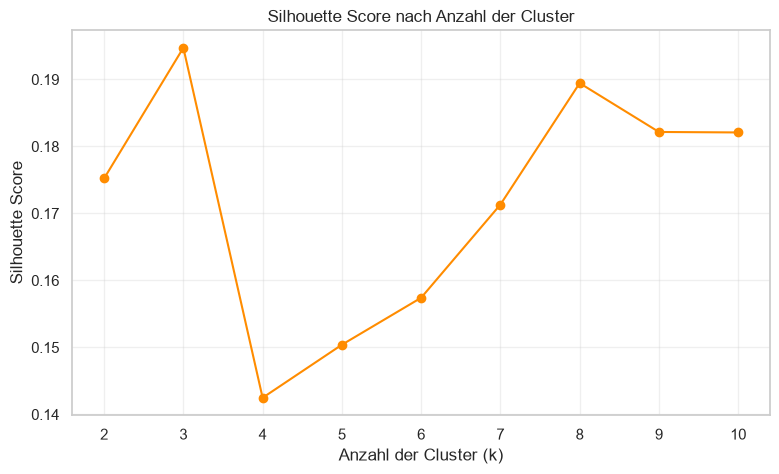

In [34]:
# Silhouette Scores visualisieren

plt.figure(figsize=(9, 5))

plt.plot(
    kmeans_evaluation["k"],
    kmeans_evaluation["silhouette_score"],
    marker="o",
    color="darkorange"
)

plt.title(
    "Silhouette Score nach Anzahl der Cluster"
)

plt.xlabel("Anzahl der Cluster (k)")
plt.ylabel("Silhouette Score")
plt.xticks(kmeans_evaluation["k"])
plt.grid(alpha=0.3)

plt.show()

In [35]:
# Größenverteilung kompakt anzeigen

cluster_size_evaluation = (
    kmeans_evaluation[
        [
            "k",
            "smallest_cluster_size",
            "smallest_cluster_share",
            "largest_cluster_size",
            "largest_cluster_share"
        ]
    ]
    .copy()
)

cluster_size_evaluation[
    "smallest_cluster_share"
] = (
    cluster_size_evaluation[
        "smallest_cluster_share"
    ] * 100
)

cluster_size_evaluation[
    "largest_cluster_share"
] = (
    cluster_size_evaluation[
        "largest_cluster_share"
    ] * 100
)

cluster_size_evaluation = (
    cluster_size_evaluation
    .rename(columns={
        "smallest_cluster_share":
            "smallest_cluster_share_percent",

        "largest_cluster_share":
            "largest_cluster_share_percent"
    })
)

display(cluster_size_evaluation)

,k,smallest_cluster_size,smallest_cluster_share_percent,largest_cluster_size,largest_cluster_share_percent
0,2,974,16.933,4778,83.067
1,3,553,9.614,4289,74.565
2,4,554,9.631,2338,40.647
3,5,386,6.711,2175,37.813
4,6,356,6.189,2013,34.997
5,7,320,5.563,1842,32.024
6,8,272,4.729,2148,37.344
7,9,261,4.538,1429,24.844
8,10,201,3.494,1345,23.383


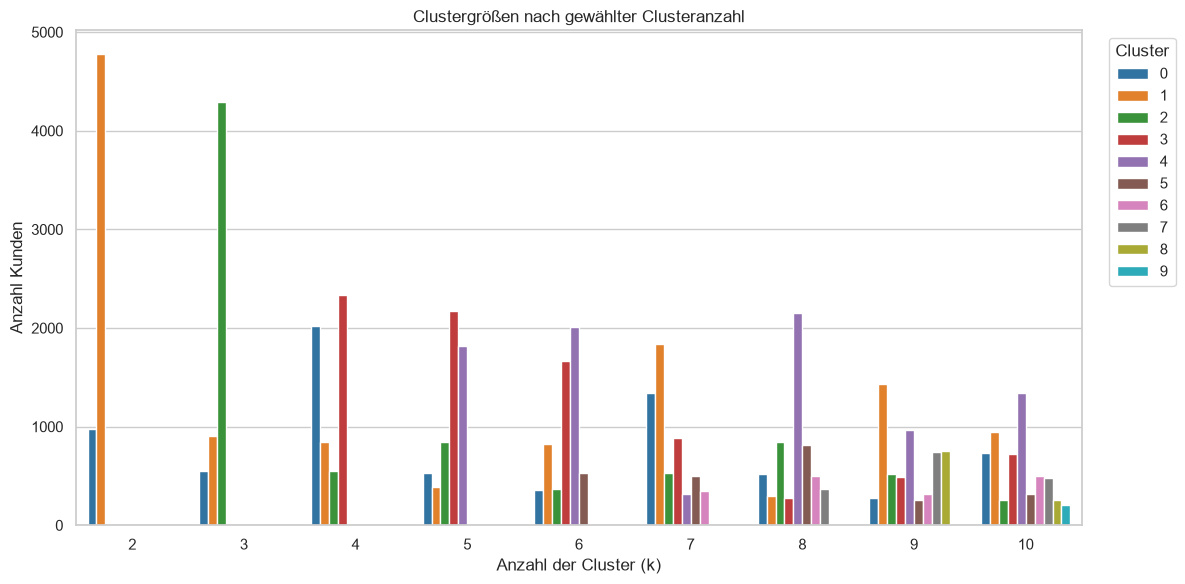

In [36]:
# Clustergrößen für alle untersuchten k-Werte darstellen

cluster_size_records = []

for k, model in kmeans_models.items():
    labels = model.labels_

    cluster_counts = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    for cluster, count in cluster_counts.items():
        cluster_size_records.append({
            "k": k,
            "cluster": cluster,
            "customer_count": count,
            "customer_share": count / len(labels)
        })


cluster_sizes_long = pd.DataFrame(
    cluster_size_records
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=cluster_sizes_long,
    x="k",
    y="customer_count",
    hue="cluster",
    palette="tab10"
)

plt.title(
    "Clustergrößen nach gewählter Clusteranzahl"
)

plt.xlabel("Anzahl der Cluster (k)")
plt.ylabel("Anzahl Kunden")
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Vorauswahl geeigneter Clusterzahlen

Die Elbow-Darstellung zeigt einen kontinuierlichen Rückgang der Inertia,
jedoch keinen eindeutig ausgeprägten Knick. Die Clusterzahl kann daher nicht
allein anhand der Elbow-Methode bestimmt werden.

Den höchsten Silhouette Score erreicht die Lösung mit drei Clustern. Dabei
werden allerdings rund 75 % aller Kunden einem einzigen Cluster zugeordnet,
während die beiden übrigen Cluster deutlich kleiner ausfallen. Diese Lösung
könnte daher hauptsächlich besondere Verhaltensgruppen vom großen
Kundenstamm abgrenzen.

Die Lösung mit acht Clustern erreicht den zweithöchsten Silhouette Score und
ermöglicht eine differenziertere Aufteilung der Kunden. Die kleinste Gruppe
umfasst noch 272 Kunden beziehungsweise rund 4,7 % der Kohorte. Eine Lösung
mit sieben Clustern weist einen etwas niedrigeren Silhouette Score, jedoch
eine vergleichsweise ausgewogene Größenverteilung auf.

Die Lösungen mit drei, sieben und acht Clustern werden deshalb im nächsten
Schritt hinsichtlich ihrer internen Qualität und ihrer fachlichen
Interpretierbarkeit genauer verglichen. Lösungen mit neun oder zehn
Clustern werden zunächst nicht weiterverfolgt, da sie kleinere Gruppen
erzeugen, ohne die Clusterqualität zu verbessern.

In [37]:
# Bibliothek importieren

from sklearn.metrics import silhouette_samples

In [38]:
# Kandidaten für den detaillierten Vergleich

candidate_k_values = [3, 7, 8]

candidate_cluster_quality = {}


for k in candidate_k_values:
    labels = kmeans_models[k].labels_

    individual_silhouette_values = silhouette_samples(
        X_scaled,
        labels
    )

    quality_data = pd.DataFrame({
        "cluster": labels,
        "silhouette_value": individual_silhouette_values
    })

    cluster_quality = (
        quality_data
        .groupby("cluster")
        .agg(
            customer_count=(
                "silhouette_value",
                "size"
            ),
            mean_silhouette=(
                "silhouette_value",
                "mean"
            ),
            median_silhouette=(
                "silhouette_value",
                "median"
            ),
            minimum_silhouette=(
                "silhouette_value",
                "min"
            )
        )
    )

    negative_shares = (
        quality_data
        .assign(
            negative_silhouette=(
                quality_data["silhouette_value"] < 0
            )
        )
        .groupby("cluster")["negative_silhouette"]
        .mean()
        .rename("negative_silhouette_share")
    )

    cluster_quality = (
        cluster_quality
        .join(negative_shares)
        .reset_index()
    )

    candidate_cluster_quality[k] = cluster_quality

    print(f"K-Means mit k = {k}")
    display(cluster_quality)

K-Means mit k = 3


,cluster,customer_count,mean_silhouette,median_silhouette,minimum_silhouette,negative_silhouette_share
0,0,553,0.157,0.162,-0.050,0.007
1,1,910,0.359,0.385,0.025,0.000
2,2,4289,0.165,0.181,-0.068,0.048


K-Means mit k = 7


,cluster,customer_count,mean_silhouette,median_silhouette,minimum_silhouette,negative_silhouette_share
0,0,1338,0.064,0.055,-0.113,0.220
1,1,1842,0.117,0.110,-0.145,0.062
2,2,527,0.119,0.126,-0.113,0.063
3,3,882,0.152,0.150,-0.101,0.006
4,4,320,0.118,0.091,-0.073,0.150
5,5,497,0.676,0.800,0.064,0.000
6,6,346,0.324,0.354,-0.046,0.009


K-Means mit k = 8


,cluster,customer_count,mean_silhouette,median_silhouette,minimum_silhouette,negative_silhouette_share
0,0,521,0.114,0.122,-0.112,0.071
1,1,295,0.118,0.135,-0.065,0.163
2,2,840,0.136,0.117,-0.096,0.025
3,3,272,0.129,0.131,-0.087,0.165
4,4,2148,0.130,0.132,-0.137,0.044
5,5,812,0.147,0.142,-0.005,0.007
6,6,498,0.676,0.802,0.056,0.000
7,7,366,0.306,0.338,-0.055,0.008


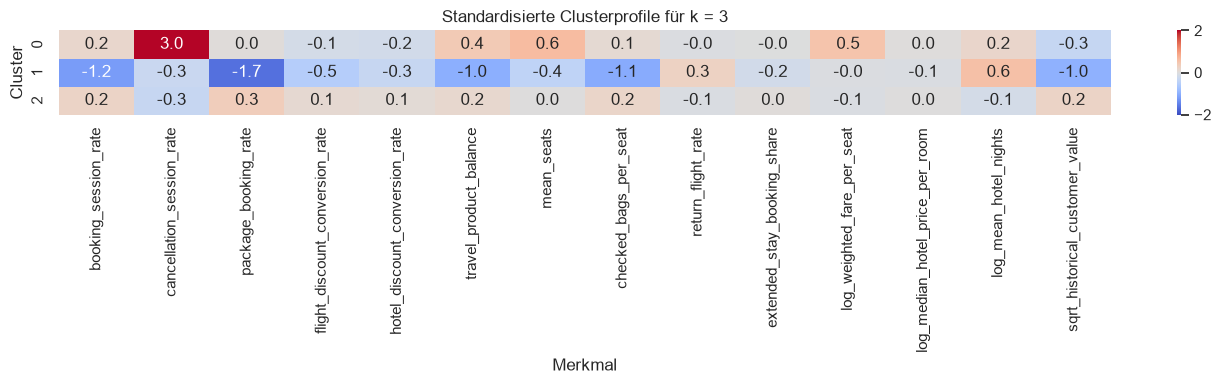

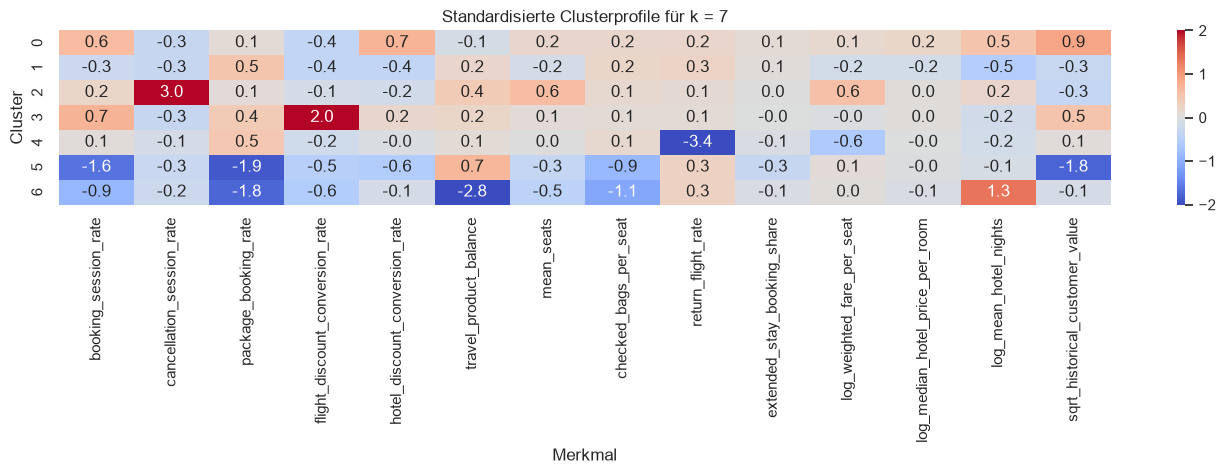

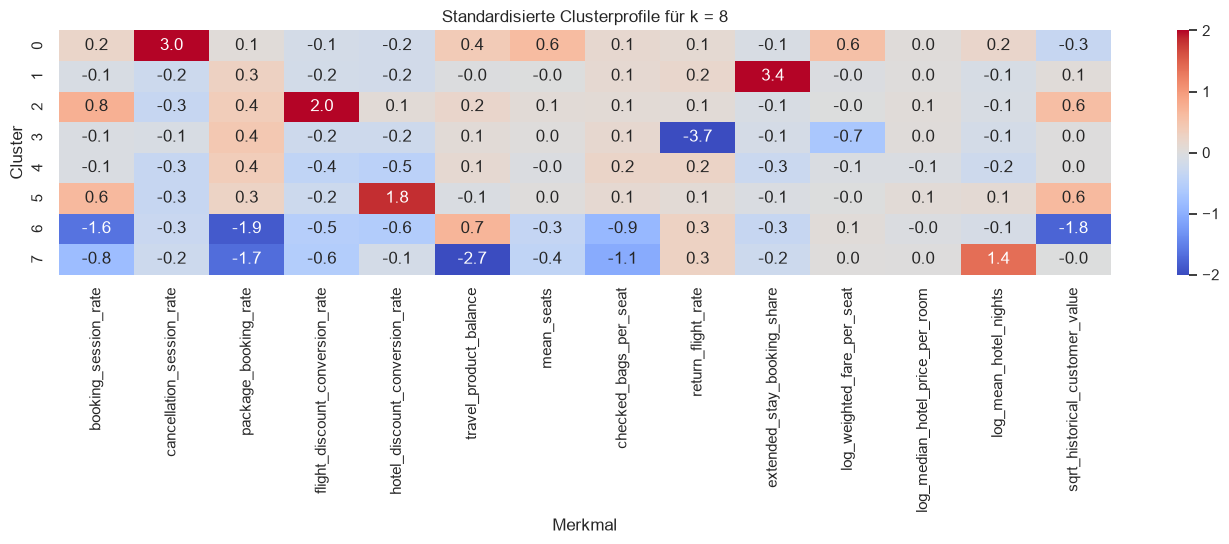

In [39]:
# Standardisierte Clusterprofile für die Kandidaten anzeigen

candidate_cluster_profiles = {}


for k in candidate_k_values:
    labels = kmeans_models[k].labels_

    profile_data = X_scaled.copy()
    profile_data["cluster"] = labels

    cluster_profile = (
        profile_data
        .groupby("cluster")
        .mean()
    )

    candidate_cluster_profiles[k] = cluster_profile

    plt.figure(figsize=(14, max(4, k * 0.7)))

    sns.heatmap(
        cluster_profile,
        cmap="coolwarm",
        center=0,
        vmin=-2,
        vmax=2,
        annot=True,
        fmt=".1f"
    )

    plt.title(
        f"Standardisierte Clusterprofile für k = {k}"
    )

    plt.xlabel("Merkmal")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

In [40]:
for k in candidate_k_values:
    labels = kmeans_models[k].labels_

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
        .rename("customer_count")
        .to_frame()
    )

    cluster_sizes["customer_share_percent"] = (
        cluster_sizes["customer_count"]
        / len(labels)
        * 100
    )

    print(f"Clustergrößen für k = {k}")
    display(cluster_sizes)

Clustergrößen für k = 3


,customer_count,customer_share_percent
0,553,9.614
1,910,15.821
2,4289,74.565


Clustergrößen für k = 7


,customer_count,customer_share_percent
0,1338,23.261
1,1842,32.024
2,527,9.162
3,882,15.334
4,320,5.563
5,497,8.640
6,346,6.015


Clustergrößen für k = 8


,customer_count,customer_share_percent
0,521,9.058
1,295,5.129
2,840,14.604
3,272,4.729
4,2148,37.344
5,812,14.117
6,498,8.658
7,366,6.363
